In [2]:
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  ...  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER
0        M   69        1  ...                      2           2          YES
1        M   74        2  ...                      2           2          YES
2        F   59        1  ...                      1           2           NO
3        M   63        2  ...                      2           2           NO
4        F   63        1  ...                      1           1           NO
..     ...  ...      ...  ...                    ...         ...          ...
304      F   56        1  ...                      2           1          YES
305      M   70        2  ...                      1           2          YES
306      M   58        2  ...                      1           2          YES
307      M   67        2  ...                      1           2          YES
308      M   62        1  ...                      2           1          YES

[309 rows x 16 columns]
      AGE  GENDER  ...  STRESS_IMMUNE  

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.93      0.96      0.95        54

    accuracy                           0.90        62
   macro avg       0.80      0.73      0.76        62
weighted avg       0.89      0.90      0.90        62


Accuracy: 0.9032
F1-Score: 0.9455
Precision: 0.9286
Recall: 0.9630
[[ 4  4]
 [ 2 52]]


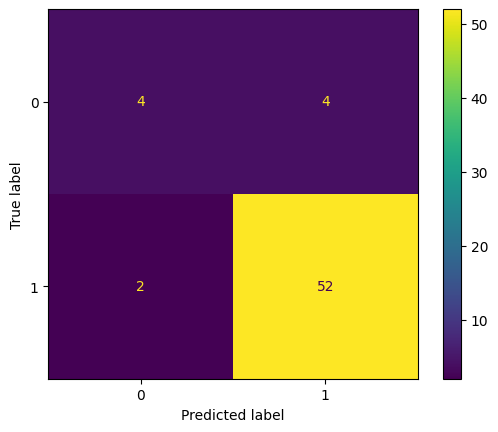


Decision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8902
Mean Precision: 0.9304
Mean Recall   : 0.9444
Mean F1-score : 0.9369

Feature Importance Ranking
                  Feature    Importance
0                ALLERGY   2.585597e-01
1                     AGE  1.741287e-01
2   SWALLOWING DIFFICULTY  1.232183e-01
3           PEER_PRESSURE  8.911700e-02
4                 ANXIETY  6.521498e-02
5       ALCOHOL CONSUMING  5.238701e-02
6                 SMOKING  4.051639e-02
7                FATIGUE   3.558585e-02
8                COUGHING  3.503602e-02
9                  GENDER  3.207988e-02
10         YELLOW_FINGERS  2.416295e-02
11               WHEEZING  2.406570e-02
12    SHORTNESS OF BREATH  2.346519e-02
13        CHRONIC DISEASE  2.246235e-02
14             CHEST PAIN  4.221499e-17


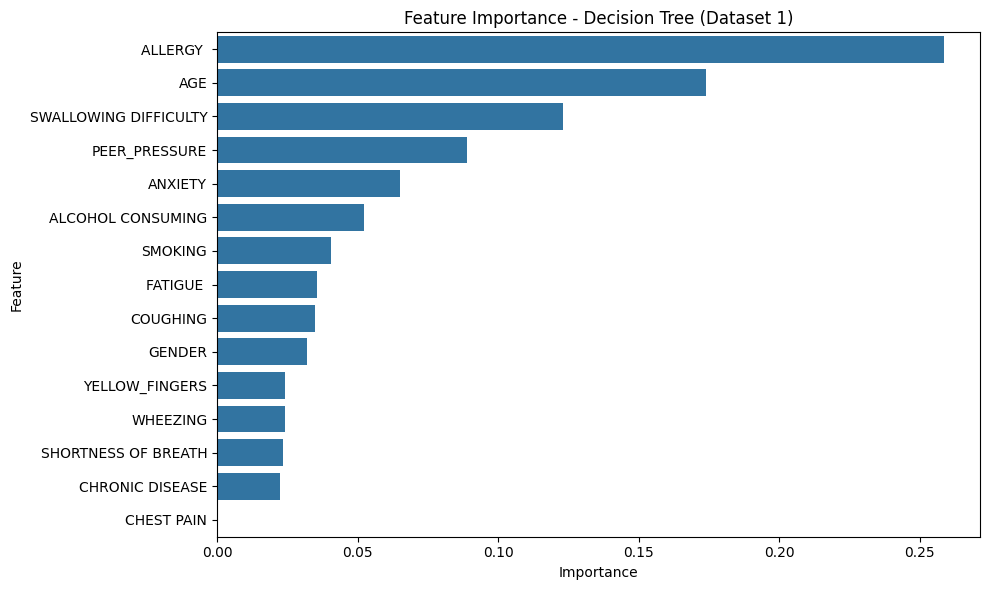


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                FATIGUE              1  0.676097   0.908446  0.700000   
1                     AGE             1  0.647488   0.904488  0.666667   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                COUGHING             1  0.640666   0.946563  0.625926   
4                ALLERGY              1  0.650714   0.970422  0.618519   
5       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
6          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8              CHEST PAIN             1  0.605182   0.930917  0.592593   
9                 SMOKING             1  0.566526   0.887825  0.574074   
10          PEER_PRESSURE             1  0.563458   0.938938  0.537037   
11                 GENDER             1  0.540561   0.897891  0.537037  

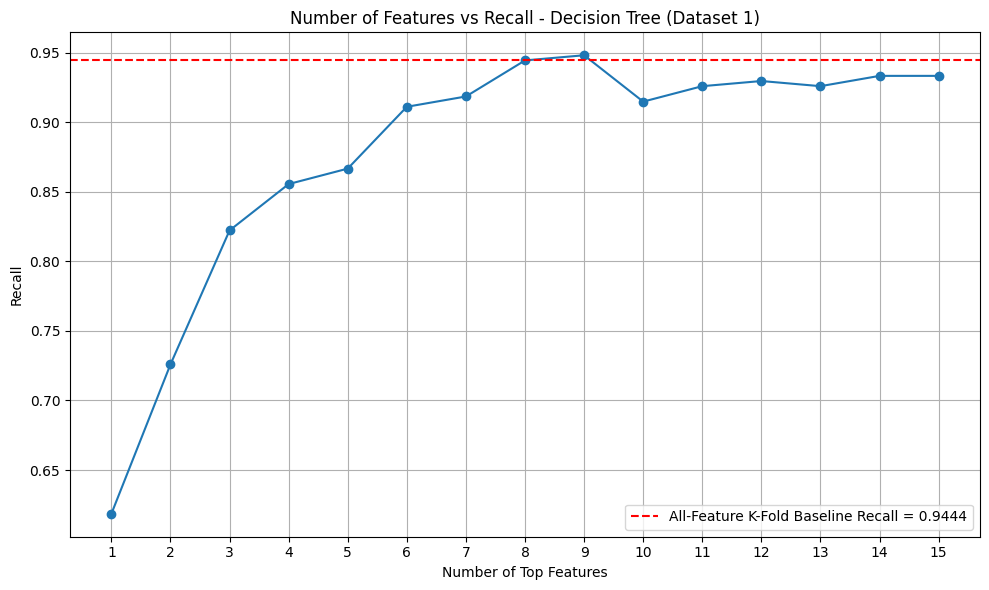

In [9]:
#Dataset 1 - Lung Cancer
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])
X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, f1_score

print(classification_report(y_test, model.predict(X_test)))


print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X1, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X1.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       575
           1       0.84      0.78      0.81       425

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000


Accuracy: 0.8430
F1-Score: 0.8092
Precision: 0.8367
Recall: 0.7835
[[510  65]
 [ 92 333]]


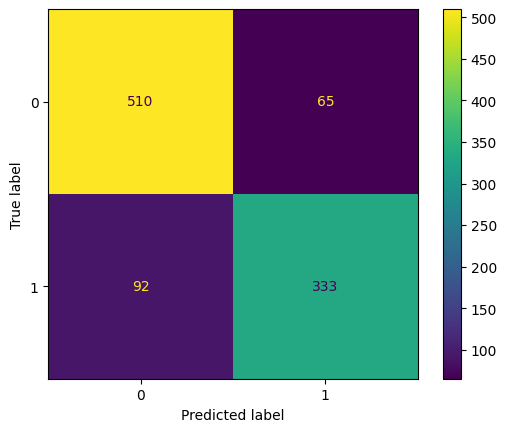


Decision Tree Results: Dataset 2 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8318
Mean Precision: 0.7966
Mean Recall   : 0.7889
Mean F1-score : 0.7924

Feature Importance Ranking
                   Feature  Importance
0                  SMOKING    0.236846
1             ENERGY_LEVEL    0.150062
2        THROAT_DISCOMFORT    0.123132
3          BREATHING_ISSUE    0.106454
4        OXYGEN_SATURATION    0.094265
5            STRESS_IMMUNE    0.081985
6                      AGE    0.061188
7           FAMILY_HISTORY    0.058305
8    EXPOSURE_TO_POLLUTION    0.038133
9          CHEST_TIGHTNESS    0.010943
10                  GENDER    0.007353
11     ALCOHOL_CONSUMPTION    0.007117
12           MENTAL_STRESS    0.005961
13         IMMUNE_WEAKNESS    0.005338
14    FINGER_DISCOLORATION    0.005280
15       LONG_TERM_ILLNESS    0.004573
16  SMOKING_FAMILY_HISTORY    0.003064


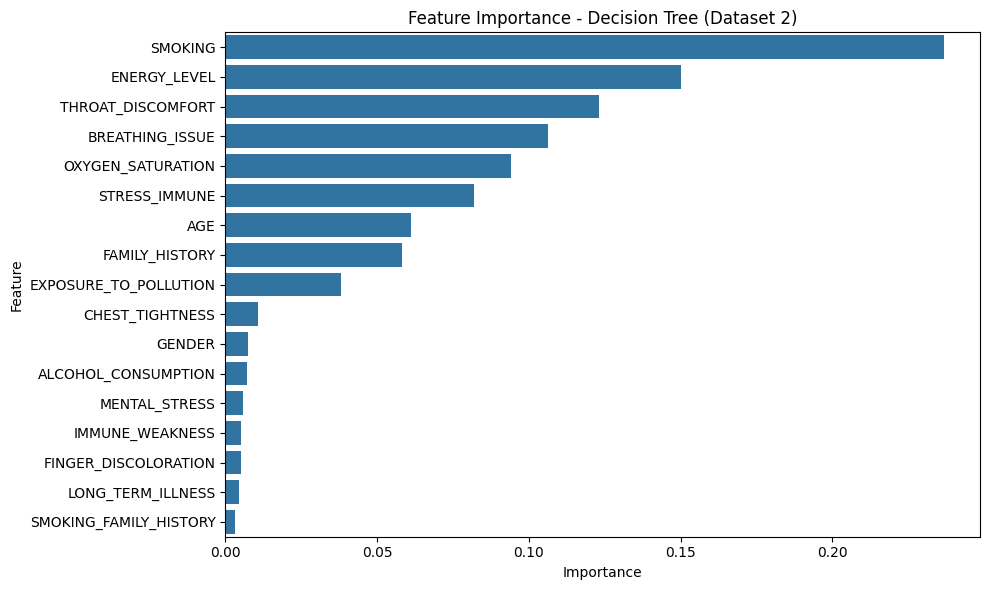


Individual Feature Results (5-Fold CV)
               Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0          BREATHING_ISSUE             1    0.5506   0.473846  0.930779   
1                  SMOKING             1    0.6830   0.567832  0.928816   
2        THROAT_DISCOMFORT             1    0.5912   0.499271  0.855173   
3     FINGER_DISCOLORATION             1    0.4938   0.417845  0.616573   
4          CHEST_TIGHTNESS             1    0.4940   0.417942  0.616111   
5            MENTAL_STRESS             1    0.5364   0.447877  0.593549   
6    EXPOSURE_TO_POLLUTION             1    0.5438   0.452914  0.573396   
7      ALCOHOL_CONSUMPTION             1    0.4832   0.391886  0.499768   
8                   GENDER             1    0.4910   0.397320  0.484042   
9          IMMUNE_WEAKNESS             1    0.5794   0.483254  0.468350   
10                     AGE             1    0.5010   0.401861  0.462419   
11       LONG_TERM_ILLNESS             1    0.5174   0.41448

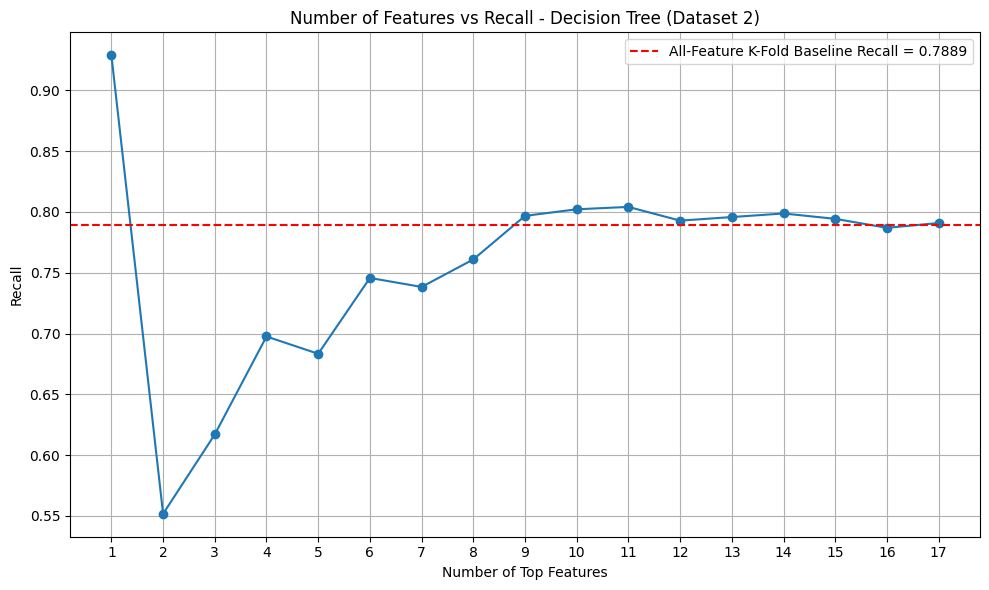

In [16]:
#Dataset 2
df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'])
X2 = df_Lung_Cancer_Prediction_Dataset.drop(columns=['PULMONARY_DISEASE'])
y2 = df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X2,y2,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X2,
    y2,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 2 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X2, y2)

feature_importance_df = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 2)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X2[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X2[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X2.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 2)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.44      0.42      0.43      3161
           1       0.74      0.75      0.74      6839

    accuracy                           0.65     10000
   macro avg       0.59      0.59      0.59     10000
weighted avg       0.64      0.65      0.64     10000


Accuracy: 0.6464
F1-Score: 0.7440
Precision: 0.7369
Recall: 0.7511
[[1327 1834]
 [1702 5137]]


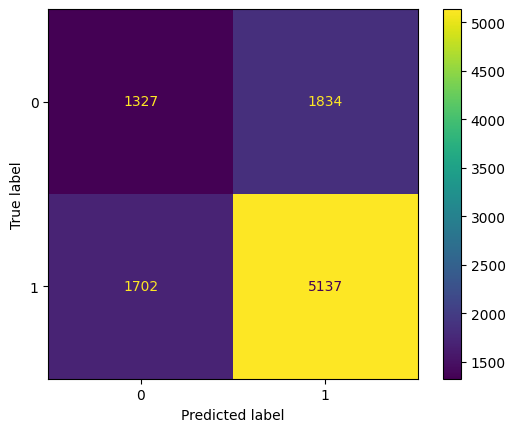


Decision Tree Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.6514
Mean Precision: 0.7437
Mean Recall   : 0.7519
Mean F1-score : 0.7478

Feature Importance Ranking
                     Feature  Importance
0                 pack_years    0.343596
1                 patient_id    0.259624
2                        age    0.194554
3             radon_exposure    0.042761
4        alcohol_consumption    0.037761
5          asbestos_exposure    0.031295
6             copd_diagnosis    0.029226
7                     gender    0.026837
8             family_history    0.017197
9  secondhand_smoke_exposure    0.017149


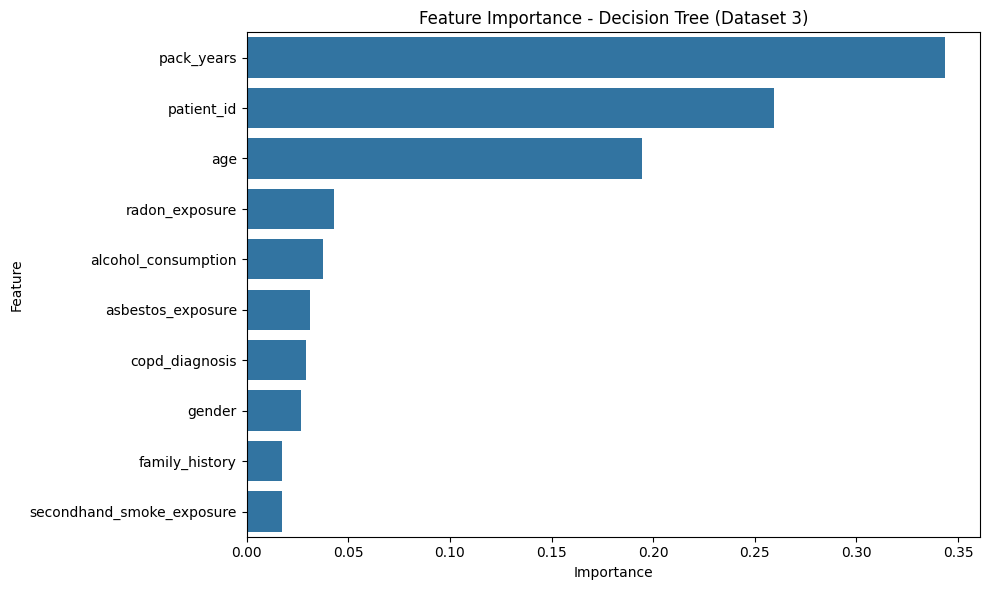


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 pack_years             1   0.61152   0.717408  0.717321   
1                 patient_id             1   0.56638   0.684500  0.684641   
2                        age             1   0.60398   0.743148  0.647625   
3             copd_diagnosis             1   0.57168   0.758276  0.553108   
4          asbestos_exposure             1   0.57182   0.760670  0.550052   
5             family_history             1   0.54942   0.736869  0.535706   
6  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
7                     gender             1   0.49478   0.682097  0.496188   
8             radon_exposure             1   0.49698   0.776887  0.376149   
9        alcohol_consumption             1   0.45400   0.710689  0.346671   

   F1-score  
0  0.717362  
1  0.684570  
2  0.692101  
3  0.639627  
4  0.638434  
5  0.620373  
6  0.617544  


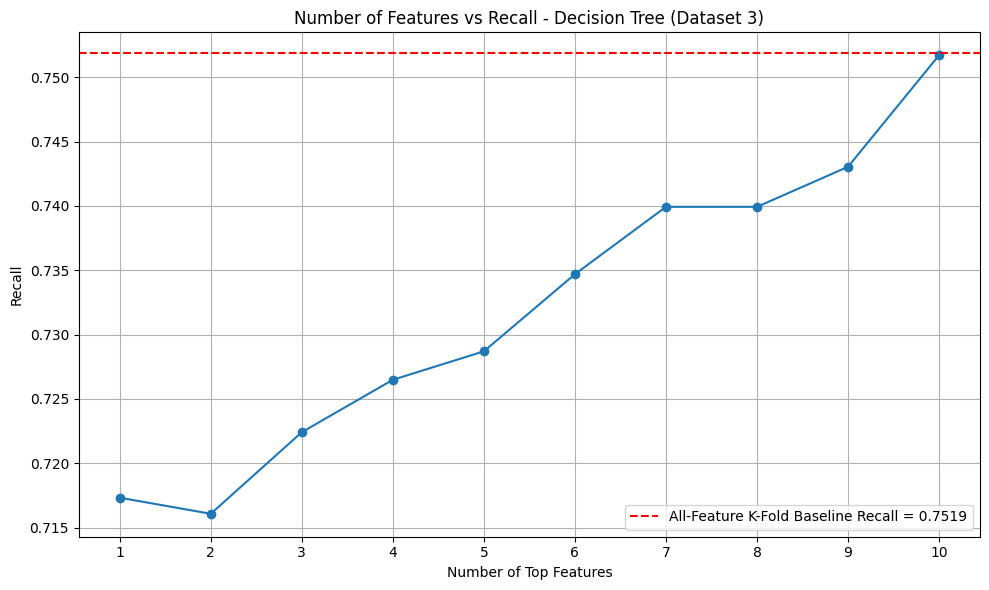

In [21]:
from matplotlib.colors import XKCD_COLORS
#Dataset 3
'''
for col in df_Lung_Cancer_Risk_Dataset.columns:
  df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col])
'''

for col in df_Lung_Cancer_Risk_Dataset.columns:
    if not pd.api.types.is_numeric_dtype(df_Lung_Cancer_Risk_Dataset[col]):
        df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col].astype(str))

X3 = df_Lung_Cancer_Risk_Dataset.drop(columns=['lung_cancer'])
y3 = df_Lung_Cancer_Risk_Dataset['lung_cancer']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X3,y3,test_size=0.2)
model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X3, y3)

feature_importance_df = pd.DataFrame({
    "Feature": X3.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X3[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X3[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X3.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 3)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
